**Welcome to pyLIMA (v2) tutorial 3b!**

In this tutorial you will learn how to use the pyLIMA simulator to simulate 
observations from space. We will also learn how to add parallax to our models.

Please take some time to familiarize yourself with the pyLIMA documentation.

In [73]:
### Import the required libraries.
%matplotlib widget

import matplotlib.pyplot as plt
from pyLIMA.models import PSPL_model
from pyLIMA.fits import TRF_fit
from pyLIMA.outputs import pyLIMA_plots
### Import the simulator to be used for generating the simulated light curve
from pyLIMA.simulations import simulator

from pyLIMA import event

Create a new EVENT object and give it a name.

You can also set the coordinates for an event.

In the context of the simulation, the coordinates will be used to check whether the target is observable from a specific observatory.

In [74]:
your_event = event.Event(ra=270, dec=-30)
your_event.name = 'My simulated event'

Create some telescope(s) to observe the event from. See tutorial 3 for more details.

We will use CTIO_I (from Earth), Gaia_G and Spitzer_H (from Space):

In [75]:
CTIO_I = simulator.simulate_a_telescope(name='CTIO_I', time_start=2458365.5, time_end=2458965.5, sampling=4, location='Earth', camera_filter='I',
                                        uniform_sampling=False, altitude=1000, longitude = -109.285399, 
                                        latitude = -27.130, bad_weather_percentage=10.0 / 100, 
                                        moon_windows_avoidance=30, minimum_alt=30, astrometry=False)

GAIA_G = simulator.simulate_a_telescope(name='GAIA_G', time_start=2458365.5, time_end=2458965.5, sampling=168, location='Space', camera_filter='G',
                                        uniform_sampling=True, spacecraft_name='Gaia', astrometry=False)

SPITZER_H = simulator.simulate_a_telescope(name='SPITZER_H', time_start=2458565.5, time_end=2458765.5, sampling=168, location='Space', camera_filter='H',
                                        uniform_sampling=True, spacecraft_name='Spitzer', astrometry=False)

your_event.telescopes.append(CTIO_I)
your_event.telescopes.append(GAIA_G)
your_event.telescopes.append(SPITZER_H)

### Run a quick sanity check on your input.
your_event.check_event()

 '2018-09-04T08:00:00.000' ... '2020-04-25T11:59:59.952'
 '2020-04-25T15:59:59.952' '2020-04-25T19:59:59.952'], location=(-1876359.2234166681, -5362421.234484145, -2891498.741933779) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron)> to <ICRS Frame>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]


check_event  : Everything looks fine...


(<Figure size 750x750 with 2 Axes>, GridPlot(id='p1076', ...))

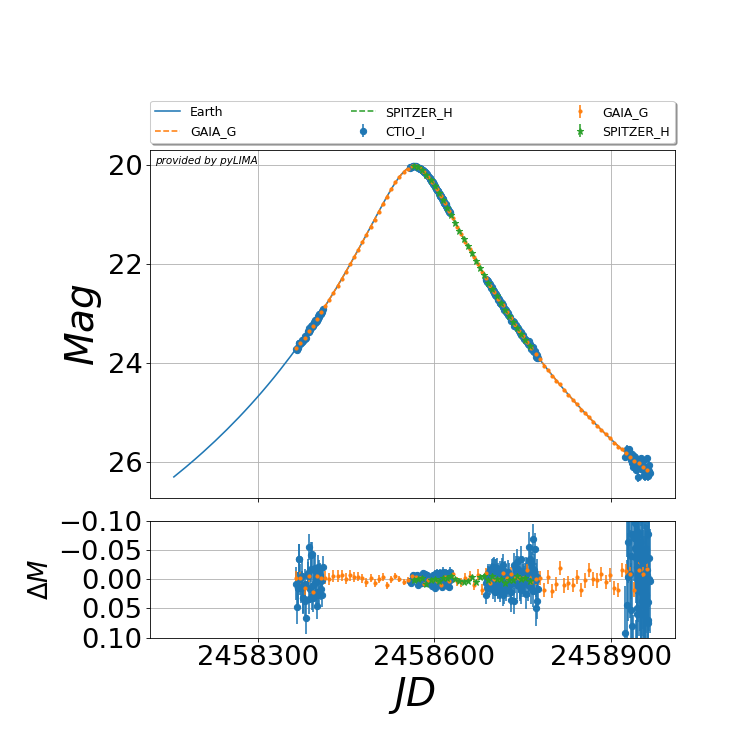

In [76]:
### We will use a simple point-lens point-source (PSPL) model without adding parallax.
pspl = PSPL_model.PSPLmodel(your_event)

### Now that the **MODEL** is there, we need to set the relevant parameters.
### pspl_parameters = [to, uo, tE, flux_source, flux_blend]
pspl_parameters = simulator.simulate_microlensing_model_parameters(pspl)

### For the purposes of this demonstration we will set the parameters to some reasonable values.
### Let's fix t0 to the value we set when we were preparing our MODEL (including parallax) above.
### This is the reference date (t0_\bar) we want to evaluate the parallax from:
pspl_parameters[0] = 2458565.25
pspl_parameters[1:5] = [0.60, 81.50, 0.02, 0.07]

### We also artificially set the source and blend fluxes of all telescopes to the same values 
### just for plotting purposes (you don't have to do this normally):

pspl_parameters[-6::2] = [10000.,10000.,10000.] # source fluxes
pspl_parameters[-6::2] = [1000.,1000.,1000.] # blend fluxes

### Transform the parameters into a pyLIMA class object.
pyLIMA_parameters_1 = pspl.compute_pyLIMA_parameters(pspl_parameters)

# Now we have defined the **MODEL** we want to simulate, we have defined the telescope details, 
# so we just inject these into our simulator to produce a light curve:
simulator.simulate_lightcurve(pspl, pyLIMA_parameters_1)

### Let's plot our simulated light curve using the pyLIMA plotter:
pyLIMA_plots.plot_lightcurves(pspl, pspl_parameters)

Parallax(Annual) estimated for the telescope CTIO_I: SUCCESS
Successfully ephemeris from JPL!
Parallax(Annual) estimated for the telescope GAIA_G: SUCCESS
Successfully ephemeris from JPL!
Parallax(Annual) estimated for the telescope SPITZER_H: SUCCESS
Parallax(Annual) estimated for the telescope CTIO_I: SUCCESS
Parallax(Annual) estimated for the telescope GAIA_G: SUCCESS
Parallax(Annual) estimated for the telescope SPITZER_H: SUCCESS
Parallax(Annual) estimated for the telescope CTIO_I: SUCCESS
Parallax(Annual) estimated for the telescope GAIA_G: SUCCESS
Parallax(Annual) estimated for the telescope SPITZER_H: SUCCESS


(<Figure size 750x750 with 2 Axes>, GridPlot(id='p1079', ...))

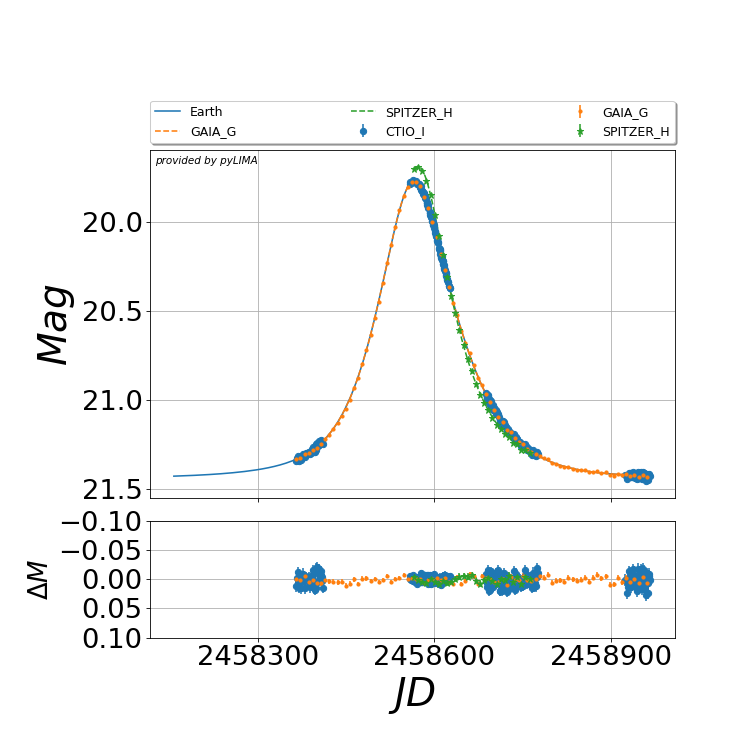

In [77]:
### Now we construct the PSPL MODEL and add annual parallax modelling.
### The reference date has to be close to t0.
pspl = PSPL_model.PSPLmodel(your_event, parallax=['Annual', 2458565.5])

### Set the relevant parameters.
# pspl_parameters = [to, uo, tE, flux_source, flux_blend]
pspl_parameters = simulator.simulate_microlensing_model_parameters(pspl)

### Set the parameters to some reasonable values.
pspl_parameters[0] = 2458565.25 # t0
pspl_parameters[1:5] = [0.60, 81.50, 0.02, 0.07]

### Set the source and blend fluxes of all telescopes to the same values for plotting purposes.
pspl_parameters[-6::2] = [10000.,10000.,10000.] # source fluxes
pspl_parameters[-6::2] = [1000.,1000.,1000.] # blend fluxes

### Transform the parameters into a pyLIMA class object.
pyLIMA_parameters_1 = pspl.compute_pyLIMA_parameters(pspl_parameters)

# Inject everthing into the simulator to produce a light curve.
simulator.simulate_lightcurve(pspl, pyLIMA_parameters_1)

### Let's plot our simulated light curve using the pyLIMA plotter.
pyLIMA_plots.plot_lightcurves(pspl, pspl_parameters)

Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS
[2458565.366700875, 0.06561658277719618, 303.4849120714434, 0.11642660522318848, 0.4961320235112334, 61957.05518060628, 193.99238386991343, 1498.5239258933248, 223.83554772124236, 6277.009647500177, 306.99097807082427]
Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS
Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS


(<Figure size 750x750 with 2 Axes>, GridPlot(id='p1085', ...))

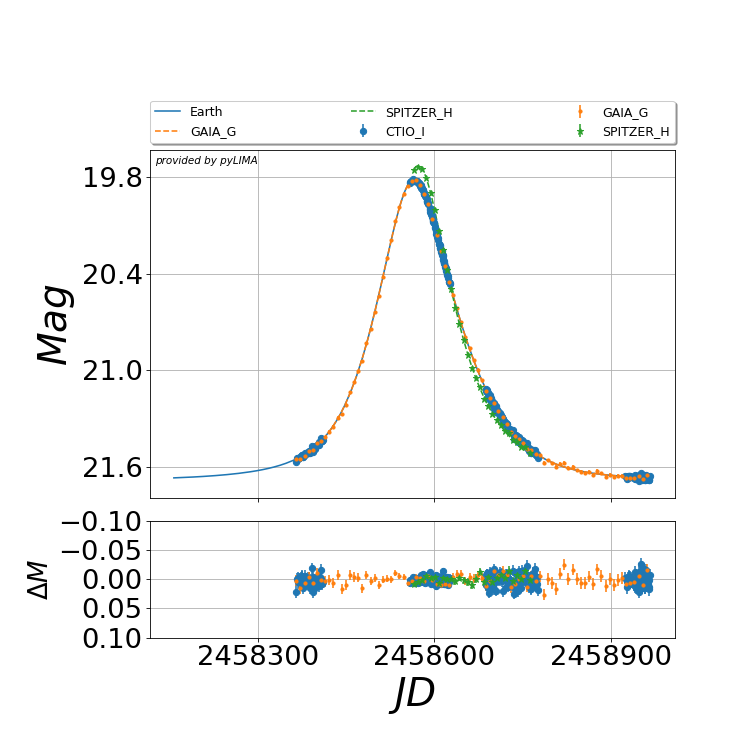

In [79]:
### Now we construct the PSPL MODEL and add full (annual & terrestrial) parallax modelling.
### The reference date has to be close to t0.
pspl = PSPL_model.PSPLmodel(your_event, parallax=['Full', 2458565.5])

### Set the relevant parameters.
# pspl_parameters = [to, uo, tE, flux_source, flux_blend]
pspl_parameters = simulator.simulate_microlensing_model_parameters(pspl)
print(pspl_parameters)

### Set the parameters to some reasonable values.
pspl_parameters[0] = 2458565.25 # t0
pspl_parameters[1:5] = [0.60, 81.50, 0.02, 0.07]

### Set the source and blend fluxes of all telescopes to the same values for plotting purposes.
pspl_parameters[-6::2] = [10000.,10000.,10000.] # source fluxes
pspl_parameters[-6::2] = [1000.,1000.,1000.] # blend fluxes

### Transform the parameters into a pyLIMA class object.
pyLIMA_parameters_1 = pspl.compute_pyLIMA_parameters(pspl_parameters)

# Inject everthing into the simulator to produce a light curve.
simulator.simulate_lightcurve(pspl, pyLIMA_parameters_1)

### Let's plot our simulated light curve using the pyLIMA plotter.
pyLIMA_plots.plot_lightcurves(pspl, pspl_parameters)